# Temporal-Difference Learning

This notebook develops **Temporal-Difference (TD) learning** from the basic idea to TD(0), TD(1), TD($\lambda$), eligibility traces, and the classic Random Walk experiment.

The notebook is organized to show both the **mathematics** and the **implementation**:

- What TD learning is and why it is called temporal-difference learning
- Relationship among Monte Carlo, Dynamic Programming, and TD
- Direct comparison of Monte Carlo and TD
- A complete episode showing how Monte Carlo and TD update differently
- TD(1) and TD(0) algorithms
- Step-by-step calculations for each algorithm
- Random Walk prediction problem
- TD(0) value-learning graph
- Empirical RMS-error comparison of Monte Carlo and TD for different learning rates
- TD($\lambda$), eligibility traces, and the backward view
- Bootstrapping and sampling

The focus here is **prediction**: estimating $v_\pi$ for a fixed policy. TD control methods such as SARSA, Q-learning, and Expected SARSA belong in a separate control notebook.

## 1. What Is Temporal-Difference Learning?

Temporal-Difference learning is a class of **model-free reinforcement-learning methods**.

TD methods learn directly from experience, so they do not require a model of the environment such as

$$
p(s',r\mid s,a).
$$

The name **temporal difference** comes from learning from the difference between estimates at different time steps.

For one-step TD, that difference is captured by the TD error

$$
\delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t).
$$

The value estimate is then updated by

$$
V(S_t)\leftarrow V(S_t)+\alpha\delta_t.
$$

The reward signal and the next-state estimate together determine how much the current estimate should change.

## 2. Relationship among Monte Carlo, Dynamic Programming, and TD

TD combines an important property of Monte Carlo with an important property of Dynamic Programming.

### Like Monte Carlo

TD learns from **sampled experience** and does not need the transition model.

### Like Dynamic Programming

TD **bootstraps**: it updates one estimate using another current estimate.

| Method | Learns from experience? | Needs environment model? | Bootstraps? | Must wait until episode ends? |
|---|---:|---:|---:|---:|
| Dynamic Programming | No | Yes | Yes | No |
| Monte Carlo | Yes | No | No | Yes |
| Temporal Difference | Yes | No | Yes | No |

The central idea is

$$
\boxed{\text{TD}=\text{sampling from experience}+\text{bootstrapping}}
$$

## 3. Monte Carlo versus Temporal Difference

This distinction is important before studying the algorithms.

### Monte Carlo

- Learns from experience.
- Must wait until the end of the episode before the complete return is known.
- Uses the actual return $G_t$ as the target.
- Does not bootstrap.
- Is naturally suited to episodic tasks.

The MC update is

$$
V(S_t)\leftarrow V(S_t)+\alpha[G_t-V(S_t)].
$$

### Temporal Difference

- Learns from experience.
- Can update before the final outcome is known.
- Uses the immediate reward plus an estimate of the next state.
- Bootstraps.
- Can be used for episodic and continuing tasks.

The one-step TD update is

$$
V(S_t)\leftarrow V(S_t)+\alpha[R_{t+1}+\gamma V(S_{t+1})-V(S_t)].
$$

### The difference in the targets

Monte Carlo:

$$
\text{Target}_{MC}=G_t
$$

TD(0):

$$
\text{Target}_{TD}=R_{t+1}+\gamma V(S_{t+1})
$$

MC waits for the **actual final return**. TD uses the **next estimate** immediately.

## 4. Driving Home Example: Why TD Can Learn Earlier

Suppose the predicted total travel time changes during one trip home:

| Situation | Elapsed time | Predicted time to go | Predicted total travel time |
|---|---:|---:|---:|
| Leaving office | 0 | 30 | 30 |
| Reach car, raining | 5 | 35 | 40 |
| Exiting highway | 20 | 15 | 35 |
| Secondary road, behind truck | 30 | 10 | 40 |
| Entering home street | 40 | 3 | 43 |
| Arrive home | 43 | 0 | 43 |

The actual travel time is **43 minutes**.

Monte Carlo would wait until arrival and compare earlier predictions with the final outcome, 43.

TD can learn during the trip by comparing each prediction with the next prediction.

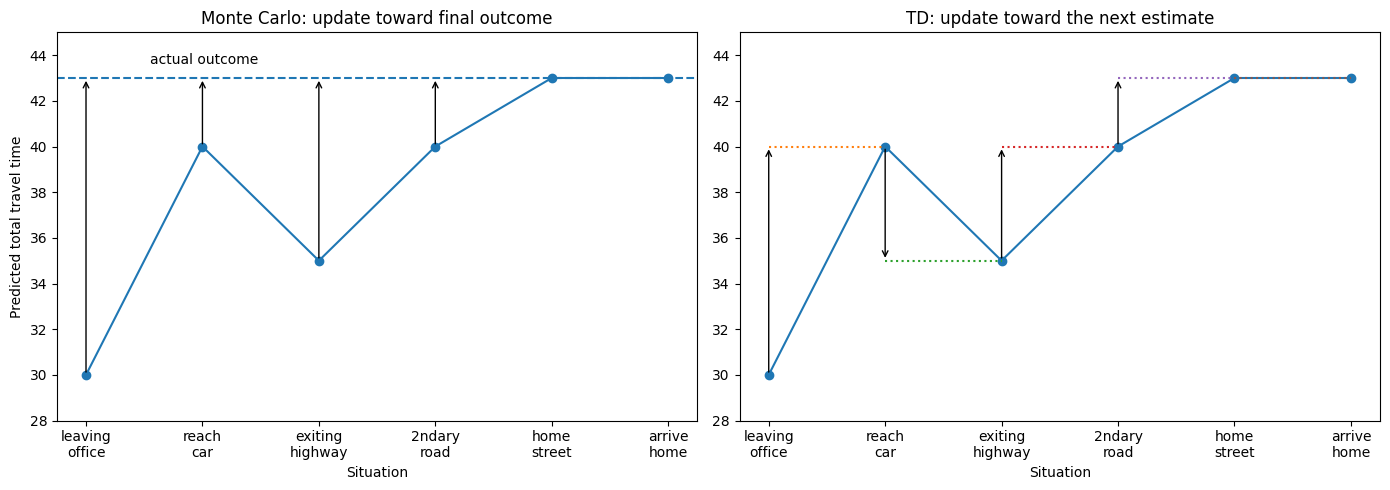

In [22]:
import numpy as np
import matplotlib.pyplot as plt

situations = ["leaving\noffice", "reach\ncar", "exiting\nhighway", "2ndary\nroad", "home\nstreet", "arrive\nhome"]
predicted_total = np.array([30, 40, 35, 40, 43, 43], dtype=float)
actual_outcome = 43.0
x = np.arange(len(situations))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, predicted_total, marker="o")
axes[0].axhline(actual_outcome, linestyle="--")

for i in range(len(x) - 1):
    axes[0].annotate("", xy=(x[i], actual_outcome), xytext=(x[i], predicted_total[i]), arrowprops=dict(arrowstyle="->"))

axes[0].text(0.55, actual_outcome + 0.6, "actual outcome")
axes[0].set_xticks(x)
axes[0].set_xticklabels(situations)
axes[0].set_ylabel("Predicted total travel time")
axes[0].set_xlabel("Situation")
axes[0].set_title("Monte Carlo: update toward final outcome")
axes[0].set_ylim(28, 45)

axes[1].plot(x, predicted_total, marker="o")

for i in range(len(x) - 1):
    axes[1].annotate("", xy=(x[i], predicted_total[i + 1]), xytext=(x[i], predicted_total[i]), arrowprops=dict(arrowstyle="->"))
    axes[1].plot([x[i], x[i + 1]], [predicted_total[i + 1], predicted_total[i + 1]], linestyle=":", linewidth=1.5)

axes[1].set_xticks(x)
axes[1].set_xticklabels(situations)
axes[1].set_xlabel("Situation")
axes[1].set_title("TD: update toward the next estimate")
axes[1].set_ylim(28, 45)

plt.tight_layout()
plt.show()

The left graph shows the Monte Carlo idea: earlier estimates can be corrected only after the final outcome becomes available.

The right graph shows the TD idea: each estimate can be corrected using information available at the **next time step**.

## 5. One Complete Episode: Monte Carlo and TD(0)

Consider the longer episode

$$
A \xrightarrow{0} B \xrightarrow{0} C \xrightarrow{0} D \xrightarrow{0} E \xrightarrow{1} \text{Terminal}.
$$

The number above each arrow is the reward received after that transition.

Use

$$
\gamma=1,\qquad \alpha=0.1.
$$

Initialize the state values as

$$
V(A)=V(B)=V(C)=V(D)=V(E)=0.5
$$

and

$$
V(\text{Terminal})=0.
$$

So initially,

$$
V(A)=V(B)=V(C)=V(D)=V(E)=0.5,\qquad V(\text{Terminal})=0.
$$

We will use this same episode to compare how **Monte Carlo** and **TD(0)** update the value estimates.

Monte Carlo will wait until the entire episode is complete and then use the observed return $G_t$.

TD(0) will update after each transition using

$$
R_{t+1}+\gamma V(S_{t+1}).
$$

### 5.1 Monte Carlo Calculation over the Episode

Monte Carlo waits until the **entire episode is complete** before updating the state values.

The episode is

$$
A \xrightarrow{0} B \xrightarrow{0} C \xrightarrow{0} D \xrightarrow{0} E \xrightarrow{1} \text{Terminal}.
$$

The return from time $t$ is

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2 R_{t+3}
+
\cdots
+
\gamma^{T-t-1}R_T.
$$

Here,

$$
\gamma=1,\qquad \alpha=0.1
$$

and initially

$$
V(A)=V(B)=V(C)=V(D)=V(E)=0.5.
$$

Because the only positive reward is received at the final transition,

$$
R_1=R_2=R_3=R_4=0,\qquad R_5=1.
$$

#### State $E$

The return from $E$ is

$$
G_4=R_5=1.
$$

Update:

$$
V(E)
\leftarrow
V(E)+\alpha[G_4-V(E)]
$$

$$
V(E)
\leftarrow
0.5+0.1(1-0.5)
$$

$$
\boxed{V(E)=0.55}
$$

#### State $D$

The return from $D$ is

$$
G_3=R_4+\gamma R_5.
$$

Therefore,

$$
G_3=0+(1)(1)=1.
$$

Update:

$$
V(D)
\leftarrow
0.5+0.1(1-0.5)
$$

$$
\boxed{V(D)=0.55}
$$

#### State $C$

The return from $C$ is

$$
G_2
=
R_3+\gamma R_4+\gamma^2R_5.
$$

Therefore,

$$
G_2
=
0+(1)(0)+(1)^2(1)
=
1.
$$

Update:

$$
V(C)
\leftarrow
0.5+0.1(1-0.5)
$$

$$
\boxed{V(C)=0.55}
$$

#### State $B$

The return from $B$ is

$$
G_1
=
R_2+\gamma R_3+\gamma^2R_4+\gamma^3R_5.
$$

Therefore,

$$
G_1
=
0+(1)(0)+(1)^2(0)+(1)^3(1)
=
1.
$$

Update:

$$
V(B)
\leftarrow
0.5+0.1(1-0.5)
$$

$$
\boxed{V(B)=0.55}
$$

#### State $A$

The return from $A$ is

$$
G_0
=
R_1+\gamma R_2+\gamma^2R_3+\gamma^3R_4+\gamma^4R_5.
$$

Therefore,

$$
G_0
=
0+(1)(0)+(1)^2(0)+(1)^3(0)+(1)^4(1)
=
1.
$$

Update:

$$
V(A)
\leftarrow
0.5+0.1(1-0.5)
$$

$$
\boxed{V(A)=0.55}
$$

### Values After the Episode

After Monte Carlo processes the completed episode,

$$
\boxed{
V(A)=V(B)=V(C)=V(D)=V(E)=0.55
}
$$

All five states receive the same update in this example because $\gamma=1$ and the return from every visited state is

$$
G_t=1.
$$

The important point is that **none of these Monte Carlo updates can be made until the final reward has been observed**.

### 5.2 TD(0) Calculation over the Same Episode

TD(0) updates the value of the current state **after every transition**.

The episode is

$$
A \xrightarrow{0} B \xrightarrow{0} C \xrightarrow{0} D \xrightarrow{0} E \xrightarrow{1} \text{Terminal}.
$$

Use

$$
\alpha=0.1,\qquad \gamma=1
$$

with initial values

$$
V(A)=V(B)=V(C)=V(D)=V(E)=0.5
$$

and

$$
V(\text{Terminal})=0.
$$

The TD(0) target is

$$
R_{t+1}+\gamma V(S_{t+1})
$$

and the TD error is

$$
\delta_t
=
R_{t+1}+\gamma V(S_{t+1})-V(S_t).
$$

The update is

$$
V(S_t)
\leftarrow
V(S_t)+\alpha\delta_t.
$$

---

#### Step 1: $A\rightarrow B$

The reward is

$$
R_1=0.
$$

The TD target is

$$
R_1+\gamma V(B)
=
0+(1)(0.5)
=
0.5.
$$

The TD error is

$$
\delta_0
=
0.5-V(A)
$$

$$
\delta_0
=
0.5-0.5
=
0.
$$

Update $A$:

$$
V(A)
\leftarrow
0.5+0.1(0)
$$

$$
\boxed{V(A)=0.5}
$$

---

#### Step 2: $B\rightarrow C$

The reward is

$$
R_2=0.
$$

The TD target is

$$
R_2+\gamma V(C)
=
0+(1)(0.5)
=
0.5.
$$

The TD error is

$$
\delta_1
=
0.5-V(B)
$$

$$
\delta_1
=
0.5-0.5
=
0.
$$

Update $B$:

$$
V(B)
\leftarrow
0.5+0.1(0)
$$

$$
\boxed{V(B)=0.5}
$$

---

#### Step 3: $C\rightarrow D$

The reward is

$$
R_3=0.
$$

The TD target is

$$
R_3+\gamma V(D)
=
0+(1)(0.5)
=
0.5.
$$

The TD error is

$$
\delta_2
=
0.5-V(C)
$$

$$
\delta_2
=
0.5-0.5
=
0.
$$

Update $C$:

$$
V(C)
\leftarrow
0.5+0.1(0)
$$

$$
\boxed{V(C)=0.5}
$$

---

#### Step 4: $D\rightarrow E$

The reward is

$$
R_4=0.
$$

At this point, $E$ has not yet been updated, so

$$
V(E)=0.5.
$$

The TD target is

$$
R_4+\gamma V(E)
=
0+(1)(0.5)
=
0.5.
$$

The TD error is

$$
\delta_3
=
0.5-V(D)
$$

$$
\delta_3
=
0.5-0.5
=
0.
$$

Update $D$:

$$
V(D)
\leftarrow
0.5+0.1(0)
$$

$$
\boxed{V(D)=0.5}
$$

---

#### Step 5: $E\rightarrow\text{Terminal}$

The final reward is

$$
R_5=1.
$$

The value of the terminal state is

$$
V(\text{Terminal})=0.
$$

The TD target is

$$
R_5+\gamma V(\text{Terminal})
=
1+(1)(0)
=
1.
$$

The TD error is

$$
\delta_4
=
1-V(E)
$$

$$
\delta_4
=
1-0.5
=
0.5.
$$

Update $E$:

$$
V(E)
\leftarrow
0.5+0.1(0.5)
$$

$$
V(E)
=
0.5+0.05
$$

$$
\boxed{V(E)=0.55}
$$

---

### Values After One Episode

After this single TD(0) episode,

$$
\boxed{
V(A)=0.5,\quad
V(B)=0.5,\quad
V(C)=0.5,\quad
V(D)=0.5,\quad
V(E)=0.55
}
$$

Notice that the final reward changes only the value of $E$ during this episode.

This happens because TD(0) uses only the **next state's current estimate**.

When the transition

$$
D\rightarrow E
$$

occurred, the value of $E$ was still

$$
V(E)=0.5.
$$

Only afterward, during

$$
E\rightarrow\text{Terminal},
$$

was $V(E)$ increased to

$$
0.55.
$$

On later episodes, the improved value of $E$ can influence $D$. Then the improved value of $D$ can influence $C$, and so on:

$$
E\rightarrow D\rightarrow C\rightarrow B\rightarrow A.
$$

This gradual backward propagation of information through estimated state values is the effect of **bootstrapping in TD(0)**.

In [23]:
states = ["A", "B", "C", "D", "E", "Terminal"]
rewards = [0.0, 0.0, 0.0, 0.0, 1.0]

alpha = 0.1
gamma = 1.0

V_demo = {
    "A": 0.5,
    "B": 0.5,
    "C": 0.5,
    "D": 0.5,
    "E": 0.5,
    "Terminal": 0.0
}

for t in range(5):
    s = states[t]
    s_next = states[t + 1]
    r = rewards[t]

    target = r + gamma * V_demo[s_next]
    delta = target - V_demo[s]

    V_demo[s] += alpha * delta

    print(
        f"Step {t + 1}: {s} -> {s_next}, "
        f"R={r:.0f}, "
        f"target={target:.2f}, "
        f"delta={delta:.2f}, "
        f"V({s})={V_demo[s]:.2f}"
    )

Step 1: A -> B, R=0, target=0.50, delta=0.00, V(A)=0.50
Step 2: B -> C, R=0, target=0.50, delta=0.00, V(B)=0.50
Step 3: C -> D, R=0, target=0.50, delta=0.00, V(C)=0.50
Step 4: D -> E, R=0, target=0.50, delta=0.00, V(D)=0.50
Step 5: E -> Terminal, R=1, target=1.00, delta=0.50, V(E)=0.55


## 6. TD(1)

For an episodic task, the forward-view TD(1) target is the full return. This gives Monte-Carlo-like behavior.

The return following time $t$ is

$$
G_t=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots+\gamma^{T-t-1}R_T.
$$

The update is

$$
V(S_t)\leftarrow V(S_t)+\alpha[G_t-V(S_t)].
$$

### How TD(1) works

A complete episode is generated. The return is then calculated backward through the episode, and each visited state is updated toward its observed return.

### TD(1) prediction algorithm

```text
Input: policy π, learning rate α, discount factor γ
Output: estimated state-value function V
Initialize V(s) arbitrarily for every nonterminal state s
Set V(terminal) = 0
For each episode:
    Generate one complete episode using policy π
    Set G = 0
    For t from the last transition to the first transition:
        Set G = R_{t+1} + γG
        Update V(S_t) = V(S_t) + α[G - V(S_t)]
Return V
```

### TD(1) step-by-step calculation

For

$$
A\xrightarrow{0}B\xrightarrow{0}C\xrightarrow{1}\text{Terminal},
$$

use

$$
\alpha=0.1,\qquad\gamma=1.
$$

At $C$:

$$
G=1+(1)(0)=1
$$

$$
V(C)\leftarrow0.5+0.1(1-0.5)=0.55
$$

At $B$:

$$
G=0+(1)(1)=1
$$

$$
V(B)\leftarrow0.5+0.1(1-0.5)=0.55
$$

At $A$:

$$
G=0+(1)(1)=1
$$

$$
V(A)\leftarrow0.5+0.1(1-0.5)=0.55
$$

## 7. TD(0): One-Step TD Prediction

TD(0) is also called **one-step TD** because it uses information only one step ahead.

The one-step target is

$$
R_{t+1}+\gamma V(S_{t+1}).
$$

The TD error is

$$
\delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t).
$$

The update is

$$
V(S_t)\leftarrow V(S_t)+\alpha\delta_t.
$$

### How TD(0) works

At each step, the agent follows policy $\pi$, observes one transition, calculates the one-step TD target, updates the value of the current state, and moves to the next state. It does not wait for the end of the episode.

### Tabular TD(0) prediction algorithm

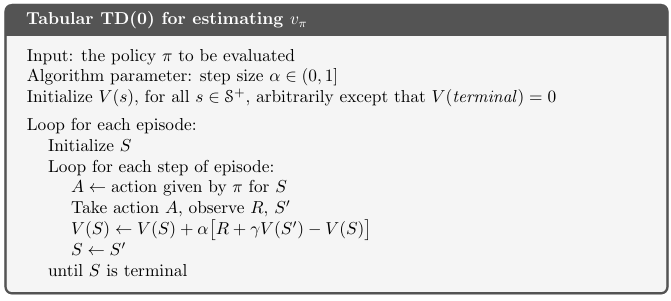

## 8. Random Walk Prediction Problem
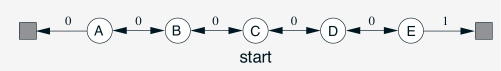

We now use the classic Random Walk problem.

There are five nonterminal states:

$$
A,\;B,\;C,\;D,\;E
$$

with terminal states on both ends.

Every episode starts from $C$.

At each nonterminal state:

$$
P(\text{left})=0.5,\qquad P(\text{right})=0.5.
$$

All transitions give reward $0$ except the transition from $E$ to the right terminal, which gives reward $1$.

The task is undiscounted:

$$
\gamma=1.
$$

Therefore, the value of a state equals the probability of eventually terminating on the right.

The true values are

$$
v_\pi(A)=\frac16,\quad
v_\pi(B)=\frac26,\quad
v_\pi(C)=\frac36,\quad
v_\pi(D)=\frac46,\quad
v_\pi(E)=\frac56.
$$

We initialize every nonterminal state at

$$
V(s)=0.5.
$$

In [24]:
NONTERMINAL = np.arange(1, 6)
START = 3
LEFT_TERMINAL = 0
RIGHT_TERMINAL = 6
TRUE_VALUES = np.arange(1, 6) / 6.0

def initial_values():
    values = np.zeros(7)
    values[1:6] = 0.5
    return values

def td0_episode(values, alpha, rng):
    state = START
    while state not in (LEFT_TERMINAL, RIGHT_TERMINAL):
        next_state = state + rng.choice([-1, 1])
        reward = 1.0 if next_state == RIGHT_TERMINAL else 0.0
        values[state] += alpha * (reward + values[next_state] - values[state])
        state = next_state

def random_walk_episode(rng):
    state = START
    episode = []
    while state not in (LEFT_TERMINAL, RIGHT_TERMINAL):
        next_state = state + rng.choice([-1, 1])
        reward = 1.0 if next_state == RIGHT_TERMINAL else 0.0
        episode.append((state, reward, next_state))
        state = next_state
    return episode

def mc_episode(values, alpha, rng):
    episode = random_walk_episode(rng)
    G = 0.0
    for state, reward, next_state in reversed(episode):
        G = reward + G
        values[state] += alpha * (G - values[state])

def rmse(values):
    return np.sqrt(np.mean((values[1:6] - TRUE_VALUES) ** 2))

## 9. TD(0) Value Estimates after Different Numbers of Episodes

Use TD(0) with

$$
\alpha=0.1.
$$

We compare the estimates after 0, 1, 10, and 100 episodes with the true values.

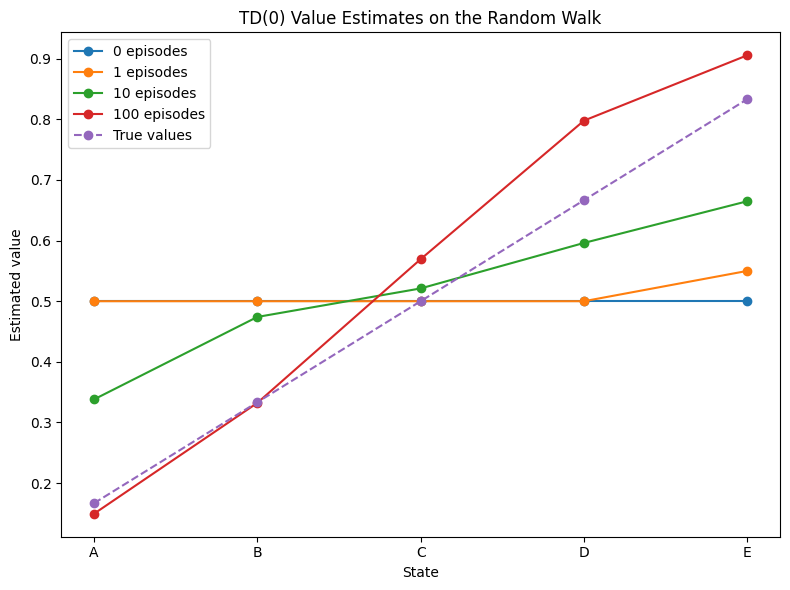

In [25]:
rng = np.random.default_rng(7)
values = initial_values()
snapshots = {0: values.copy()}

for episode in range(1, 101):
    td0_episode(values, 0.1, rng)
    if episode in [1, 10, 100]:
        snapshots[episode] = values.copy()

state_x = np.arange(5)
state_labels = ["A", "B", "C", "D", "E"]

plt.figure(figsize=(8, 6))
for episode in [0, 1, 10, 100]:
    plt.plot(state_x, snapshots[episode][1:6], marker="o", label=f"{episode} episodes")
plt.plot(state_x, TRUE_VALUES, marker="o", linestyle="--", label="True values")
plt.xticks(state_x, state_labels)
plt.xlabel("State")
plt.ylabel("Estimated value")
plt.title("TD(0) Value Estimates on the Random Walk")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Root-Mean-Square Error

The prediction error is measured using root-mean-square error:

$$
\operatorname{RMSE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(\hat v_i-v_i)^2
}.
$$

For the five nonterminal states,

$$
\operatorname{RMSE}
=
\sqrt{
\frac{
[V(A)-v_\pi(A)]^2+
[V(B)-v_\pi(B)]^2+
[V(C)-v_\pi(C)]^2+
[V(D)-v_\pi(D)]^2+
[V(E)-v_\pi(E)]^2
}{5}
}.
$$

A smaller RMSE means the estimated value function is closer to the true value function.

In [26]:
print("Initial RMSE:", rmse(initial_values()))
print("RMSE after 100 TD(0) episodes:", rmse(snapshots[100]))

Initial RMSE: 0.23570226039551584
RMSE after 100 TD(0) episodes: 0.07425833063024939


## 11. Empirical RMS Error: TD(0) versus Monte Carlo

This experiment compares TD(0) and constant-step-size Monte Carlo for different learning rates.

For TD(0):

$$
\alpha\in\{0.05,\;0.10,\;0.15\}.
$$

For Monte Carlo:

$$
\alpha\in\{0.01,\;0.02,\;0.03,\;0.04\}.
$$

For each learning rate:

1. Initialize all nonterminal values to $0.5$.
2. Run 100 episodes.
3. Compute RMSE after every episode.
4. Repeat the experiment over 100 independent runs.
5. Average the RMSE across runs.

This produces the empirical learning curves.

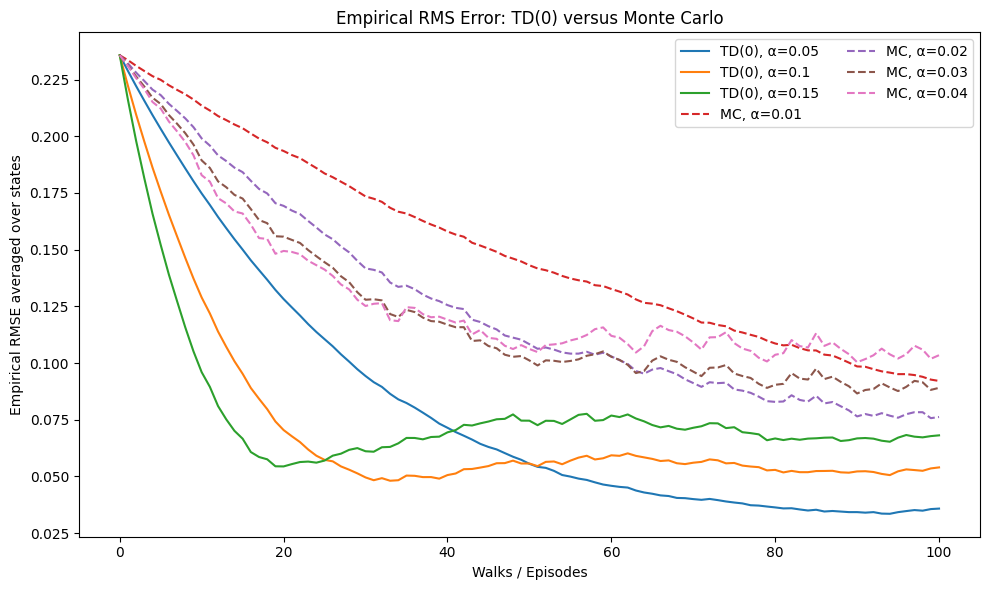

In [27]:
def average_rmse_curve(method, alpha, runs=100, episodes=100):
    errors = np.zeros(episodes + 1)
    for run in range(runs):
        rng = np.random.default_rng(run)
        values = initial_values()
        errors[0] += rmse(values)
        for episode in range(1, episodes + 1):
            method(values, alpha, rng)
            errors[episode] += rmse(values)
    return errors / runs

episodes = np.arange(101)
td_alphas = [0.05, 0.10, 0.15]
mc_alphas = [0.01, 0.02, 0.03, 0.04]

td_curves = {alpha: average_rmse_curve(td0_episode, alpha) for alpha in td_alphas}
mc_curves = {alpha: average_rmse_curve(mc_episode, alpha) for alpha in mc_alphas}

plt.figure(figsize=(10, 6))
for alpha in td_alphas:
    plt.plot(episodes, td_curves[alpha], label=f"TD(0), α={alpha}")
for alpha in mc_alphas:
    plt.plot(episodes, mc_curves[alpha], linestyle="--", label=f"MC, α={alpha}")
plt.xlabel("Walks / Episodes")
plt.ylabel("Empirical RMSE averaged over states")
plt.title("Empirical RMS Error: TD(0) versus Monte Carlo")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

The graph should be interpreted by comparing methods at the same episode count. Lower curves indicate smaller prediction error.

Because the learning rate changes the size of each update, the best-looking curve is not determined by the method name alone. The experiment therefore compares several $\alpha$ values for both TD and MC.

In [28]:
print("Final RMSE after 100 episodes")
print("-" * 36)
for alpha in td_alphas:
    print(f"TD(0)  alpha={alpha:0.2f}: {td_curves[alpha][-1]:.4f}")
for alpha in mc_alphas:
    print(f"MC     alpha={alpha:0.2f}: {mc_curves[alpha][-1]:.4f}")

Final RMSE after 100 episodes
------------------------------------
TD(0)  alpha=0.05: 0.0358
TD(0)  alpha=0.10: 0.0540
TD(0)  alpha=0.15: 0.0681
MC     alpha=0.01: 0.0921
MC     alpha=0.02: 0.0762
MC     alpha=0.03: 0.0891
MC     alpha=0.04: 0.1035


## 12. Reproducing the Two Random-Walk Graphs Together

The left panel shows TD(0) value estimates after different numbers of episodes.

The right panel shows empirical RMS error for TD(0) and Monte Carlo at different learning rates.

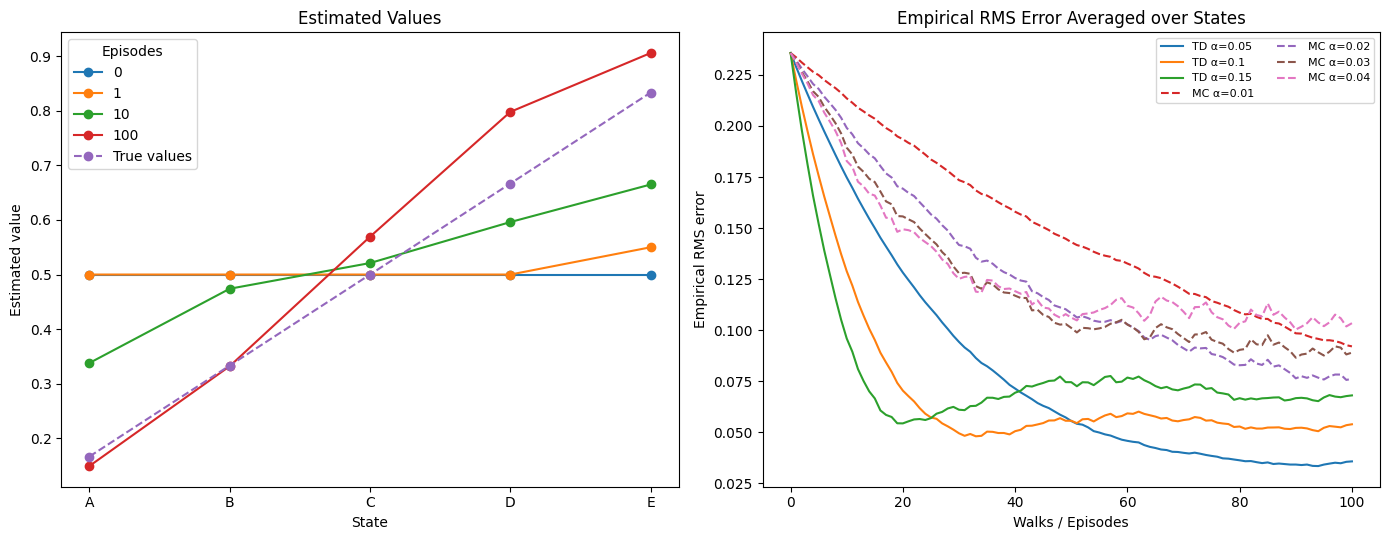

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for episode in [0, 1, 10, 100]:
    axes[0].plot(state_x, snapshots[episode][1:6], marker="o", label=str(episode))
axes[0].plot(state_x, TRUE_VALUES, marker="o", linestyle="--", label="True values")
axes[0].set_xticks(state_x)
axes[0].set_xticklabels(state_labels)
axes[0].set_xlabel("State")
axes[0].set_ylabel("Estimated value")
axes[0].set_title("Estimated Values")
axes[0].legend(title="Episodes")

for alpha in td_alphas:
    axes[1].plot(episodes, td_curves[alpha], label=f"TD α={alpha}")
for alpha in mc_alphas:
    axes[1].plot(episodes, mc_curves[alpha], linestyle="--", label=f"MC α={alpha}")
axes[1].set_xlabel("Walks / Episodes")
axes[1].set_ylabel("Empirical RMS error")
axes[1].set_title("Empirical RMS Error Averaged over States")
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

## 13. TD($\lambda$)

TD(0) uses one-step bootstrapping.

Monte Carlo uses the complete return.

TD($\lambda$) creates a family of methods between these two ideas:

$$
0\leq\lambda\leq1.
$$

When

$$
\lambda=0,
$$

the method reduces to TD(0).

As $\lambda$ increases, the current TD error can assign learning credit farther back to recently visited states.

For episodic prediction, the $\lambda=1$ endpoint has Monte-Carlo-like full-return behavior.

There are two common views of TD($\lambda$):

- **Forward view:** combines multi-step returns.
- **Backward view:** uses eligibility traces.

## 14. Eligibility Traces

The backward view introduces an additional memory variable for every state:

$$
e_t(s).
$$

For an accumulating eligibility trace,

$$
e_t(s)=
\begin{cases}
\gamma\lambda e_{t-1}(s), & s\neq S_t,\\
\gamma\lambda e_{t-1}(s)+1, & s=S_t.
\end{cases}
$$

The same expression can be written compactly as

$$
e_t(s)=\gamma\lambda e_{t-1}(s)+\mathbf{1}(s=S_t).
$$

The trace becomes larger when a state is visited and then gradually decays.

The current TD error is

$$
\delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t).
$$

Every state is updated according to its current trace:

$$
V(s)\leftarrow V(s)+\alpha\delta_t e_t(s).
$$

States visited more recently or more frequently have larger eligibility and therefore receive more of the current learning signal.

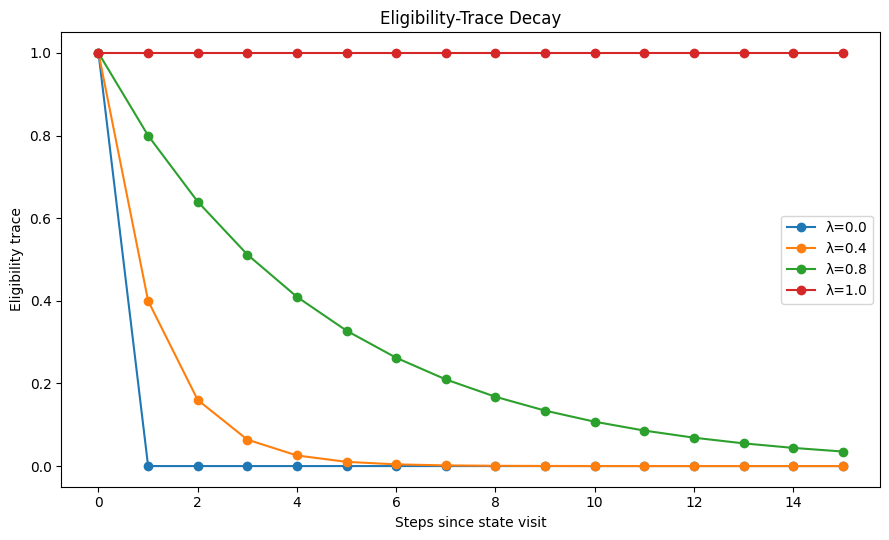

In [30]:
steps = np.arange(16)
gamma = 1.0

plt.figure(figsize=(9, 5.5))
for lam in [0.0, 0.4, 0.8, 1.0]:
    trace = (gamma * lam) ** steps
    plt.plot(steps, trace, marker="o", label=f"λ={lam}")
plt.xlabel("Steps since state visit")
plt.ylabel("Eligibility trace")
plt.title("Eligibility-Trace Decay")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Backward-View TD($\lambda$) Prediction Algorithm

### How the algorithm works

At the start of every episode, all eligibility traces are zero. After each transition, calculate the TD error. Increase the trace of the current state. Use that same TD error to update every state according to its trace. Then decay all traces by $\gamma\lambda$.

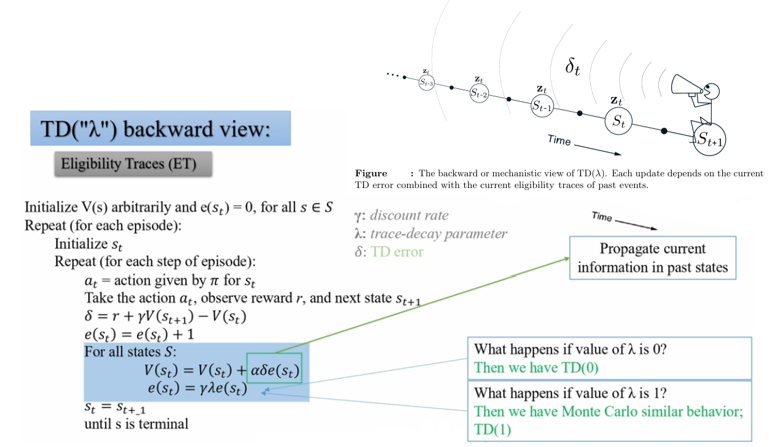

## 16. TD($\lambda$) Step-by-Step Calculation with a Longer Episode

Consider the episode

$$
A\xrightarrow{0}B\xrightarrow{0}C\xrightarrow{0}D\xrightarrow{0}E\xrightarrow{1}\text{Terminal}
$$

where the number above each arrow is the reward received after the transition.

Use

$$
\alpha=0.1,\qquad \gamma=1,\qquad \lambda=0.8.
$$

Initially,

$$
V(A)=V(B)=V(C)=V(D)=V(E)=0.5
$$

and all eligibility traces are zero:

$$
e(A)=e(B)=e(C)=e(D)=e(E)=0.
$$

For backward-view TD($\lambda$), we use

$$
\delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t)
$$

and

$$
e(S_t)\leftarrow e(S_t)+1.
$$

Then every state is updated using

$$
V(s)\leftarrow V(s)+\alpha\delta_t e(s)
$$

and the traces decay according to

$$
e(s)\leftarrow\gamma\lambda e(s).
$$

### Step 1: $A\rightarrow B$

The reward is

$$
R_1=0.
$$

The TD error is

$$
\delta_0
=
R_1+\gamma V(B)-V(A)
$$

$$
\delta_0
=
0+(1)(0.5)-0.5
=
0.
$$

Increase the eligibility trace of the current state $A$:

$$
e(A)=0+1=1.
$$

Because

$$
\delta_0=0,
$$

no value is changed.

Now decay the eligibility traces:

$$
e(A)=\gamma\lambda e(A)
$$

$$
e(A)=(1)(0.8)(1)=0.8.
$$

Therefore, after Step 1:

$$
e(A)=0.8.
$$

### Step 2: $B\rightarrow C$

The reward is

$$
R_2=0.
$$

The TD error is

$$
\delta_1
=
R_2+\gamma V(C)-V(B)
$$

$$
\delta_1
=
0+(1)(0.5)-0.5
=
0.
$$

Increase the trace of $B$:

$$
e(B)=1.
$$

Before decay,

$$
e(A)=0.8,\qquad e(B)=1.
$$

Because

$$
\delta_1=0,
$$

the values remain unchanged.

Now decay all traces:

$$
e(A)=(1)(0.8)(0.8)=0.64
$$

and

$$
e(B)=(1)(0.8)(1)=0.8.
$$

Therefore,

$$
e(A)=0.64,\qquad e(B)=0.8.
$$

### Step 3: $C\rightarrow D$

The reward is

$$
R_3=0.
$$

The TD error is

$$
\delta_2
=
R_3+\gamma V(D)-V(C)
$$

$$
\delta_2
=
0+(1)(0.5)-0.5
=
0.
$$

Increase the trace of $C$:

$$
e(C)=1.
$$

Before decay,

$$
e(A)=0.64,\qquad
e(B)=0.8,\qquad
e(C)=1.
$$

Because

$$
\delta_2=0,
$$

there is no value update.

After decay:

$$
e(A)=0.64(0.8)=0.512
$$

$$
e(B)=0.8(0.8)=0.64
$$

$$
e(C)=1(0.8)=0.8.
$$

Therefore,

$$
e(A)=0.512,\qquad
e(B)=0.64,\qquad
e(C)=0.8.
$$

### Step 4: $D\rightarrow E$

The reward is

$$
R_4=0.
$$

The TD error is

$$
\delta_3
=
R_4+\gamma V(E)-V(D)
$$

$$
\delta_3
=
0+(1)(0.5)-0.5
=
0.
$$

Increase the trace of $D$:

$$
e(D)=1.
$$

Before decay,

$$
e(A)=0.512,\qquad
e(B)=0.64,\qquad
e(C)=0.8,\qquad
e(D)=1.
$$

Again,

$$
\delta_3=0,
$$

so no value changes.

After decay:

$$
e(A)=0.512(0.8)=0.4096
$$

$$
e(B)=0.64(0.8)=0.512
$$

$$
e(C)=0.8(0.8)=0.64
$$

$$
e(D)=1(0.8)=0.8.
$$

Therefore,

$$
e(A)=0.4096,\qquad
e(B)=0.512,\qquad
e(C)=0.64,\qquad
e(D)=0.8.
$$

### Step 5: $E\rightarrow\text{Terminal}$

Now the agent receives the final reward

$$
R_5=1.
$$

The terminal-state value is

$$
V(\text{Terminal})=0.
$$

Therefore, the TD error is

$$
\delta_4
=
R_5+\gamma V(\text{Terminal})-V(E)
$$

$$
\delta_4
=
1+(1)(0)-0.5
$$

$$
\boxed{\delta_4=0.5}.
$$

Increase the eligibility trace of $E$:

$$
e(E)=1.
$$

Before updating the values, the traces are therefore

$$
e(A)=0.4096
$$

$$
e(B)=0.512
$$

$$
e(C)=0.64
$$

$$
e(D)=0.8
$$

$$
e(E)=1.
$$

### Updating All Previously Visited States

The update equation is

$$
V(s)\leftarrow V(s)+\alpha\delta_4e(s).
$$

#### State $A$

$$
V(A)
\leftarrow
0.5+(0.1)(0.5)(0.4096)
$$

$$
V(A)
=
0.5+0.02048
$$

$$
\boxed{V(A)=0.52048}.
$$

#### State $B$

$$
V(B)
\leftarrow
0.5+(0.1)(0.5)(0.512)
$$

$$
V(B)
=
0.5+0.0256
$$

$$
\boxed{V(B)=0.5256}.
$$

#### State $C$

$$
V(C)
\leftarrow
0.5+(0.1)(0.5)(0.64)
$$

$$
V(C)
=
0.5+0.032
$$

$$
\boxed{V(C)=0.532}.
$$

#### State $D$

$$
V(D)
\leftarrow
0.5+(0.1)(0.5)(0.8)
$$

$$
V(D)
=
0.5+0.04
$$

$$
\boxed{V(D)=0.54}.
$$

#### State $E$

$$
V(E)
\leftarrow
0.5+(0.1)(0.5)(1)
$$

$$
V(E)
=
0.5+0.05
$$

$$
\boxed{V(E)=0.55}.
$$

### Final Values After the Episode

After one episode,

$$
V(A)=0.52048
$$

$$
V(B)=0.5256
$$

$$
V(C)=0.532
$$

$$
V(D)=0.54
$$

$$
V(E)=0.55.
$$

Notice that the states closer to the final reward receive larger updates.

The final TD error was

$$
\delta_4=0.5,
$$

but its effect was weighted by the eligibility trace of each state:

$$
A:\quad e(A)=0.4096
$$

$$
B:\quad e(B)=0.512
$$

$$
C:\quad e(C)=0.64
$$

$$
D:\quad e(D)=0.8
$$

$$
E:\quad e(E)=1.
$$

Therefore,

$$
\boxed{
\text{older states receive less credit, while more recent states receive more credit}
}
$$

because their traces decay by

$$
\gamma\lambda=(1)(0.8)=0.8
$$

at every step.

In [31]:
alpha = 0.1
gamma = 1.0
lam = 0.8

V = {"A": 0.5, "B": 0.5, "C": 0.5, "D": 0.5, "E": 0.5, "Terminal": 0.0}

e = {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "Terminal": 0.0}

trajectory = [
    ("A", 0.0, "B"),
    ("B", 0.0, "C"),
    ("C", 0.0, "D"),
    ("D", 0.0, "E"),
    ("E", 1.0, "Terminal")
]

states = ["A", "B", "C", "D", "E"]

for step, (s, r, s_next) in enumerate(trajectory, start=1):
    delta = r + gamma * V[s_next] - V[s]

    e[s] += 1.0

    for state in states:
        V[state] += alpha * delta * e[state]

    print(f"Step {step}: {s} -> {s_next}")
    print(f"TD error = {delta:.4f}")
    print(f"Values: V(A)={V['A']:.5f}, V(B)={V['B']:.5f}, V(C)={V['C']:.5f}, V(D)={V['D']:.5f}, V(E)={V['E']:.5f}")
    print(f"Traces before decay: e(A)={e['A']:.4f}, e(B)={e['B']:.4f}, e(C)={e['C']:.4f}, e(D)={e['D']:.4f}, e(E)={e['E']:.4f}")

    for state in states:
        e[state] *= gamma * lam

    print(f"Traces after decay:  e(A)={e['A']:.4f}, e(B)={e['B']:.4f}, e(C)={e['C']:.4f}, e(D)={e['D']:.4f}, e(E)={e['E']:.4f}")
    print()

Step 1: A -> B
TD error = 0.0000
Values: V(A)=0.50000, V(B)=0.50000, V(C)=0.50000, V(D)=0.50000, V(E)=0.50000
Traces before decay: e(A)=1.0000, e(B)=0.0000, e(C)=0.0000, e(D)=0.0000, e(E)=0.0000
Traces after decay:  e(A)=0.8000, e(B)=0.0000, e(C)=0.0000, e(D)=0.0000, e(E)=0.0000

Step 2: B -> C
TD error = 0.0000
Values: V(A)=0.50000, V(B)=0.50000, V(C)=0.50000, V(D)=0.50000, V(E)=0.50000
Traces before decay: e(A)=0.8000, e(B)=1.0000, e(C)=0.0000, e(D)=0.0000, e(E)=0.0000
Traces after decay:  e(A)=0.6400, e(B)=0.8000, e(C)=0.0000, e(D)=0.0000, e(E)=0.0000

Step 3: C -> D
TD error = 0.0000
Values: V(A)=0.50000, V(B)=0.50000, V(C)=0.50000, V(D)=0.50000, V(E)=0.50000
Traces before decay: e(A)=0.6400, e(B)=0.8000, e(C)=1.0000, e(D)=0.0000, e(E)=0.0000
Traces after decay:  e(A)=0.5120, e(B)=0.6400, e(C)=0.8000, e(D)=0.0000, e(E)=0.0000

Step 4: D -> E
TD error = 0.0000
Values: V(A)=0.50000, V(B)=0.50000, V(C)=0.50000, V(D)=0.50000, V(E)=0.50000
Traces before decay: e(A)=0.5120, e(B)=0.6400, 

## 17. Bootstrapping and Sampling

### Monte Carlo

Monte Carlo uses sampled experience.

Its target is

$$
G_t.
$$

It does not bootstrap because $G_t$ does not contain another current value estimate.

### Dynamic Programming

Dynamic Programming bootstraps through the Bellman expectation equation:

$$
v_\pi(s)
=
\sum_a\pi(a\mid s)
\sum_{s',r}
p(s',r\mid s,a)
\left[r+\gamma v_\pi(s')\right].
$$

DP uses a model and averages over possible transitions.

### Temporal Difference

TD samples an actual transition,

$$
S_t,R_{t+1},S_{t+1},
$$

but its target contains the estimated next-state value,

$$
R_{t+1}+\gamma V(S_{t+1}).
$$

Therefore TD uses **sampling and bootstrapping together**.

## 18. Final Comparison

| Property | Monte Carlo | TD(0) | TD($\lambda$) |
|---|---|---|---|
| Learns from experience | Yes | Yes | Yes |
| Needs a model | No | No | No |
| Updates before episode ends | No | Yes | Yes |
| Bootstraps | No | Yes | Yes |
| Uses full return directly | Yes | No | Depends on $\lambda$ |
| Can assign credit to several recent states at one step | No | No | Yes |

The main equations are:

### Monte Carlo / full-return target

$$
V(S_t)\leftarrow V(S_t)+\alpha[G_t-V(S_t)]
$$

### TD(0)

$$
V(S_t)\leftarrow V(S_t)+\alpha[R_{t+1}+\gamma V(S_{t+1})-V(S_t)]
$$

### TD($\lambda$)

$$
\delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t)
$$

$$
e_t(s)=\gamma\lambda e_{t-1}(s)+\mathbf{1}(s=S_t)
$$

$$
V(s)\leftarrow V(s)+\alpha\delta_t e_t(s)
$$

## 19. What This Notebook Demonstrates

This notebook moves from the conceptual difference between Monte Carlo and TD to reproducible prediction experiments.

The code demonstrates:

- one-step online TD updates,
- full-return Monte Carlo updates,
- the classic five-state Random Walk,
- value estimates approaching the true state values,
- empirical RMSE curves for several learning rates,
- and eligibility-trace credit assignment in TD($\lambda$).

The next natural topic is **TD control**, where the agent learns action values and improves its policy using methods such as SARSA, Q-learning, and Expected SARSA.